In [1]:
# Initial Setup
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import librosa
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc
import time
import warnings
warnings.filterwarnings('ignore')

class Config:
    ROOT = '/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup'
    STEMS_PATH = os.path.join(ROOT, 'genres_stems')
    ESC50_PATH = os.path.join(ROOT, 'ESC-50-master', 'audio')
    MASHUPS_PATH = os.path.join(ROOT, 'mashups')
    TEST_CSV = os.path.join(ROOT, 'test.csv')

    GENRES = ["blues", "classical", "country", "disco", "hiphop",
              "jazz", "metal", "pop", "reggae", "rock"]
    NUM_CLASSES = len(GENRES)

    SAMPLE_RATE = 22050
    DURATION = 10
    FULL_DURATION = 30
    N_MELS = 128
    N_FFT = 2048
    HOP_LENGTH = 512

    N_SAMPLES = SAMPLE_RATE * DURATION
    FULL_SAMPLES = SAMPLE_RATE * FULL_DURATION

    BATCH_SIZE = 64
    EPOCHS = 30
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    RANDOM_STATE = 42

    TRAIN_SAMPLES = 8000
    VAL_SAMPLES = 1500
    MASHUPS_PER_GENRE = 200

    SNR_LO, SNR_HI = 10, 28
    VOL_LO, VOL_HI = 0.75, 1.25
    MIXUP_P = 0.3
    MIXUP_ALPHA = 0.3
    LABEL_SMOOTH = 0.05
    SPEC_AUG_P = 0.5
    FM_PARAM = 20
    TM_PARAM = 40

    TTA_CROPS = 7

config = Config()
torch.manual_seed(config.RANDOM_STATE)
np.random.seed(config.RANDOM_STATE)
random.seed(config.RANDOM_STATE)

if torch.cuda.is_available():
    n_gpus = torch.cuda.device_count()
    for i in range(n_gpus):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)} ({torch.cuda.get_device_properties(i).total_memory/1e9:.1f}GB)")
else:
    n_gpus = 0
    print("CPU only")

GPU 0: Tesla T4 (15.6GB)
GPU 1: Tesla T4 (15.6GB)


In [2]:
# Audio Cache and Processing

class StemCache:
    def __init__(self, stems_path, noise_path, sr):
        self.sr = sr
        self.data = {}
        self.noises = []

        print("Caching audio...")
        self._cache_stems(stems_path)
        self._cache_noise(noise_path)
        n_stems = sum(len(songs) for songs in self.data.values())
        print(f"Cached: {n_stems} songs, {len(self.noises)} noise clips")

    def _load(self, p, dur=None):
        try:
            y, _ = librosa.load(p, sr=self.sr, duration=dur, mono=True)
            return y.astype(np.float32)
        except:
            return np.zeros(self.sr * 5, dtype=np.float32)

    def _cache_stems(self, path):
        stems_list = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']
        for gdir in tqdm(sorted(os.listdir(path)), desc="Stems"):
            gpath = os.path.join(path, gdir)
            if not os.path.isdir(gpath) or gdir not in config.GENRES:
                continue
            self.data[gdir] = {}
            for sdir in sorted(os.listdir(gpath)):
                spath = os.path.join(gpath, sdir)
                if not os.path.isdir(spath):
                    continue
                song_stems = {}
                for st in stems_list:
                    sp = os.path.join(spath, st)
                    if os.path.exists(sp):
                        song_stems[st] = self._load(sp, dur=30)
                if song_stems:
                    self.data[gdir][sdir] = song_stems

    def _cache_noise(self, path):
        from glob import glob
        for nf in tqdm(glob(os.path.join(path, '*.wav')), desc="Noise"):
            audio = self._load(nf, dur=5)
            if len(audio) > 1000:
                self.noises.append(audio)

    def get_stems(self, genre):
        if genre not in self.data or len(self.data[genre]) < 4:
            return {}
        songs = list(self.data[genre].keys())
        picked = random.sample(songs, 4)
        stem_names = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']
        out = {}
        for i, sn in enumerate(stem_names):
            sid = picked[i % len(picked)]
            if sn in self.data[genre][sid]:
                out[sn] = self.data[genre][sid][sn].copy()
        return out

    def get_noise(self):
        if not self.noises:
            return np.zeros(self.sr * 5, dtype=np.float32)
        return random.choice(self.noises).copy()


class AudioProcessor:
    @staticmethod
    def normalize(x):
        mx = np.abs(x).max()
        return x / mx * 0.95 if mx > 1e-8 else x

    @staticmethod
    def rms_norm(x, db=-20.0):
        rms = np.sqrt(np.mean(x**2))
        if rms < 1e-8:
            return x
        target = 10 ** (db / 20)
        return np.clip(x * (target / rms), -1.0, 1.0)

    @staticmethod
    def add_noise(clean, noise, snr):
        if len(noise) < len(clean):
            reps = int(np.ceil(len(clean) / len(noise)))
            noise = np.tile(noise, reps)[:len(clean)]
        else:
            st = random.randint(0, max(0, len(noise) - len(clean)))
            noise = noise[st:st + len(clean)]
        cp = np.mean(clean**2) + 1e-10
        np_ = np.mean(noise**2) + 1e-10
        scale = np.sqrt(cp / (10 ** (snr / 10)) / np_)
        return AudioProcessor.normalize(clean + noise * scale)

    @staticmethod
    def pad_trim(x, length):
        if len(x) < length:
            return np.pad(x, (0, length - len(x)))
        return x[:length]

    @staticmethod
    def rand_crop(x, length):
        if len(x) <= length:
            return AudioProcessor.pad_trim(x, length)
        st = random.randint(0, len(x) - length)
        return x[st:st + length]

    @staticmethod
    def to_mel(audio, sr, n_mels=128, n_fft=2048, hop_length=512):
        S = librosa.feature.melspectrogram(
            y=audio, sr=sr, n_mels=n_mels,
            n_fft=n_fft, hop_length=hop_length
        )
        S_db = librosa.power_to_db(S, ref=np.max)
        return torch.from_numpy(S_db).float()


cache = StemCache(config.STEMS_PATH, config.ESC50_PATH, config.SAMPLE_RATE)
ap = AudioProcessor()
gc.collect()

Caching audio...


Noise: 100%|██████████| 2000/2000 [00:25<00:00, 78.55it/s]

Cached: 1000 songs, 2000 noise clips


57158

In [3]:
# Mashup Creation

def create_mashup(genre, is_train=True):
    full_len = config.FULL_SAMPLES
    stems = cache.get_stems(genre)
    if not stems:
        return np.zeros(full_len, dtype=np.float32)

    mix = np.zeros(full_len, dtype=np.float32)
    items = list(stems.items())

    # Stem dropout
    if is_train and random.random() < 0.08:
        n_keep = random.randint(2, len(items))
        items = random.sample(items, n_keep)

    for name, audio in items:
        audio = ap.pad_trim(audio, full_len)
        vol = random.uniform(config.VOL_LO, config.VOL_HI) if is_train else 1.0
        mix += audio * vol

    mix = ap.rms_norm(mix, -20.0)

    # Add noise at random positions
    n_noise = random.randint(1, 3) if is_train else random.randint(1, 2)
    for _ in range(n_noise):
        noise = cache.get_noise()
        snr = random.uniform(config.SNR_LO, config.SNR_HI)
        nf = np.zeros(full_len, dtype=np.float32)
        if len(noise) < full_len:
            st = random.randint(0, full_len - len(noise))
            nf[st:st + len(noise)] = noise
        else:
            nf = noise[:full_len]
        mix = ap.add_noise(mix, nf, snr)

    return mix

In [4]:
# Datasets

class TrainDataset(Dataset):
    def __init__(self, n_samples, is_val=False):
        self.n = n_samples
        self.is_val = is_val
        self.aug = not is_val

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        genre = random.choice(config.GENRES)
        label = config.GENRES.index(genre)

        audio = create_mashup(genre, is_train=self.aug)
        crop = ap.rand_crop(audio, config.N_SAMPLES)

        mel = ap.to_mel(crop, config.SAMPLE_RATE,
                        config.N_MELS, config.N_FFT, config.HOP_LENGTH)
        mel = mel.unsqueeze(0)  

        # SpecAugment
        if self.aug and random.random() < config.SPEC_AUG_P:
            mel = self._spec_augment(mel)

        # Label
        lbl = torch.zeros(config.NUM_CLASSES, dtype=torch.float32)

        if self.aug and random.random() < config.MIXUP_P:
            g2 = random.choice(config.GENRES)
            l2 = config.GENRES.index(g2)
            a2 = create_mashup(g2, is_train=True)
            c2 = ap.rand_crop(a2, config.N_SAMPLES)
            m2 = ap.to_mel(c2, config.SAMPLE_RATE,
                           config.N_MELS, config.N_FFT, config.HOP_LENGTH).unsqueeze(0)
            if random.random() < config.SPEC_AUG_P:
                m2 = self._spec_augment(m2)
            lam = np.random.beta(config.MIXUP_ALPHA, config.MIXUP_ALPHA)
            mel = lam * mel + (1 - lam) * m2
            lbl[label] = lam
            lbl[l2] += (1 - lam)
        else:
            ls = config.LABEL_SMOOTH
            lbl.fill_(ls / config.NUM_CLASSES)
            lbl[label] = 1.0 - ls + ls / config.NUM_CLASSES

        return mel, lbl

    def _spec_augment(self, spec):
        spec = spec.clone()
        _, H, W = spec.shape
        # Freq masks
        for _ in range(2):
            f = random.randint(1, min(config.FM_PARAM, H - 1))
            f0 = random.randint(0, H - f)
            spec[:, f0:f0+f, :] = 0
        # Time masks
        for _ in range(2):
            t = random.randint(1, min(config.TM_PARAM, W - 1))
            t0 = random.randint(0, W - t)
            spec[:, :, t0:t0+t] = 0
        return spec


class TestDataset(Dataset):
    def __init__(self, mashup_dir, test_df, n_crops=7):
        self.mdir = mashup_dir
        self.df = test_df
        self.n_crops = n_crops

    def __len__(self):
        return len(self.df)

    def _load(self, aid):
        fname = f"song{str(aid).zfill(4)}.wav"
        path = os.path.join(self.mdir, fname)
        try:
            y, _ = librosa.load(path, sr=config.SAMPLE_RATE, duration=30, mono=True)
            y = ap.pad_trim(y, config.FULL_SAMPLES)
            y = ap.normalize(y)
            return y.astype(np.float32)
        except:
            return np.zeros(config.FULL_SAMPLES, dtype=np.float32)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        aid = row['id']
        audio = self._load(aid)

        crops = []
        clen = config.N_SAMPLES
        total = len(audio)
        if total <= clen:
            audio = ap.pad_trim(audio, clen)
            mel = ap.to_mel(audio, config.SAMPLE_RATE,
                            config.N_MELS, config.N_FFT, config.HOP_LENGTH).unsqueeze(0)
            crops = [mel] * self.n_crops
        else:
            max_st = total - clen
            starts = np.linspace(0, max_st, self.n_crops, dtype=int)
            for st in starts:
                crop = audio[st:st + clen]
                mel = ap.to_mel(crop, config.SAMPLE_RATE,
                                config.N_MELS, config.N_FFT, config.HOP_LENGTH).unsqueeze(0)
                crops.append(mel)

        return str(aid), torch.stack(crops)

In [5]:
# CNN Model Architecture

class AudioCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(AudioCNN, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.global_pool(x)
        x = self.fc(x)
        return x

In [6]:
# Training Utilities

class SoftCE(nn.Module):
    def forward(self, logits, targets):
        lp = F.log_softmax(logits, dim=-1)
        return -(targets * lp).sum(dim=-1).mean()


def train_epoch(model, dataloader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    n_batch = 0

    for spectrograms, labels in dataloader:
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        with autocast():
            outputs = model(spectrograms)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        n_batch += 1

    return running_loss / n_batch


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for spectrograms, labels in dataloader:
            spectrograms = spectrograms.to(device)
            labels = labels.to(device)

            with autocast():
                outputs = model(spectrograms)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.argmax(1).cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    per_cls = f1_score(all_labels, all_preds, average=None)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, macro_f1, per_cls


def predict_tta(model, test_dl, device):
    model.eval()
    preds = {}
    probs = {}

    with torch.no_grad():
        for aids, crops in tqdm(test_dl, desc="Inference"):
            bs, nc = crops.shape[:2]
            flat = crops.view(-1, *crops.shape[2:]).to(device)
            with autocast():
                logits = model(flat)
            p = F.softmax(logits, dim=1)
            p = p.view(bs, nc, -1).mean(dim=1)
            pred_idx = p.argmax(dim=1)
            for i, aid in enumerate(aids):
                preds[aid] = config.GENRES[pred_idx[i].item()]
                probs[aid] = p[i].cpu().numpy()

    return preds, probs

In [7]:
# Data Preparation

total_start = time.time()

label_to_idx = {genre: idx for idx, genre in enumerate(config.GENRES)}
idx_to_label = {v: k for k, v in label_to_idx.items()}

print("Creating datasets...")
train_dataset = TrainDataset(config.TRAIN_SAMPLES, is_val=False)
val_dataset = TrainDataset(config.VAL_SAMPLES, is_val=True)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

model = AudioCNN(num_classes=config.NUM_CLASSES)
if n_gpus >= 2:
    model = nn.DataParallel(model)
    print(f"Using {n_gpus} GPUs")
model = model.to(config.DEVICE)

criterion = SoftCE()
optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

total_steps = len(train_loader) * config.EPOCHS
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=config.LEARNING_RATE, total_steps=total_steps,
    pct_start=0.05, anneal_strategy='cos'
)
scaler = GradScaler()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Creating datasets...
Training samples: 8000
Validation samples: 1500
Using 2 GPUs

Total parameters: 1,735,498
Trainable parameters: 1,735,498


In [8]:
# Model Training

best_f1 = 0.0
best_epoch = 0
patience = 0
max_patience = 10

metrics = {
    'train_loss': [], 'val_loss': [],
    'val_acc': [], 'val_f1': []
}

print("\nTraining...")
for epoch in range(config.EPOCHS):
    t0 = time.time()
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler, config.DEVICE)
    val_loss, val_acc, val_f1, per_cls = validate(model, val_loader, criterion, config.DEVICE)

    metrics['train_loss'].append(train_loss)
    metrics['val_loss'].append(val_loss)
    metrics['val_acc'].append(val_acc)
    metrics['val_f1'].append(val_f1)

    elapsed = time.time() - t0
    cls_str = " ".join(f"{config.GENRES[i][:3]}:{per_cls[i]:.3f}" for i in range(config.NUM_CLASSES))

    print(f"Epoch {epoch+1}/{config.EPOCHS} - Train Loss: {train_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f} ({elapsed:.0f}s)")
    print(f"  {cls_str}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_epoch = epoch + 1
        patience = 0
        state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save({'state': state, 'f1': best_f1, 'epoch': best_epoch}, '/kaggle/working/best_cnn.pth')
        print(f"  -> New best: {val_f1:.4f}")
    else:
        patience += 1
        if patience >= max_patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

print(f"\nBest Validation - F1: {best_f1:.4f} at epoch {best_epoch}")


Training...
Epoch 1/30 - Train Loss: 2.1456, Val Loss: 1.8636, Val Acc: 0.4107, Val F1: 0.3377 (498s)
  blu:0.291 cla:0.545 cou:0.029 dis:0.271 hip:0.515 jaz:0.162 met:0.549 pop:0.500 reg:0.429 roc:0.086
  -> New best: 0.3377
Epoch 2/30 - Train Loss: 1.8698, Val Loss: 1.5485, Val Acc: 0.5233, Val F1: 0.4847 (485s)
  blu:0.480 cla:0.682 cou:0.316 dis:0.331 hip:0.560 jaz:0.355 met:0.750 pop:0.603 reg:0.480 roc:0.290
  -> New best: 0.4847
Epoch 3/30 - Train Loss: 1.7106, Val Loss: 1.4380, Val Acc: 0.5687, Val F1: 0.5569 (489s)
  blu:0.449 cla:0.682 cou:0.420 dis:0.417 hip:0.698 jaz:0.405 met:0.835 pop:0.616 reg:0.536 roc:0.512
  -> New best: 0.5569
Epoch 4/30 - Train Loss: 1.5815, Val Loss: 1.2783, Val Acc: 0.6387, Val F1: 0.6124 (488s)
  blu:0.507 cla:0.822 cou:0.565 dis:0.529 hip:0.725 jaz:0.500 met:0.856 pop:0.677 reg:0.540 roc:0.402
  -> New best: 0.6124
Epoch 5/30 - Train Loss: 1.5007, Val Loss: 1.1535, Val Acc: 0.7013, Val F1: 0.6926 (487s)
  blu:0.621 cla:0.921 cou:0.539 dis:0.623


 ----- CLASSIFICATION REPORT -----
              precision    recall  f1-score   support

       blues     0.8417    0.8298    0.8357       141
   classical     0.9760    0.9819    0.9790       166
     country     0.8254    0.9017    0.8619       173
       disco     0.8639    0.8467    0.8552       150
      hiphop     0.9248    0.8786    0.9011       140
        jazz     0.8654    0.9712    0.9153       139
       metal     0.9281    0.9699    0.9485       133
         pop     0.9065    0.9197    0.9130       137
      reggae     0.9379    0.7861    0.8553       173
        rock     0.7740    0.7635    0.7687       148

    accuracy                         0.8833      1500
   macro avg     0.8844    0.8849    0.8834      1500
weighted avg     0.8849    0.8833    0.8827      1500




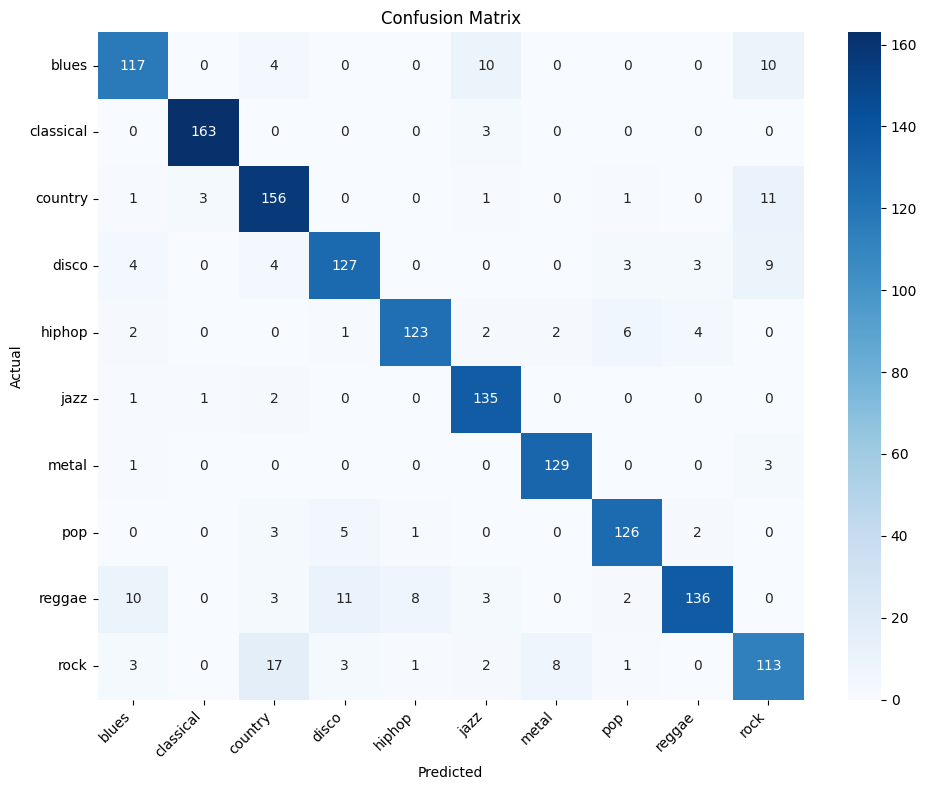

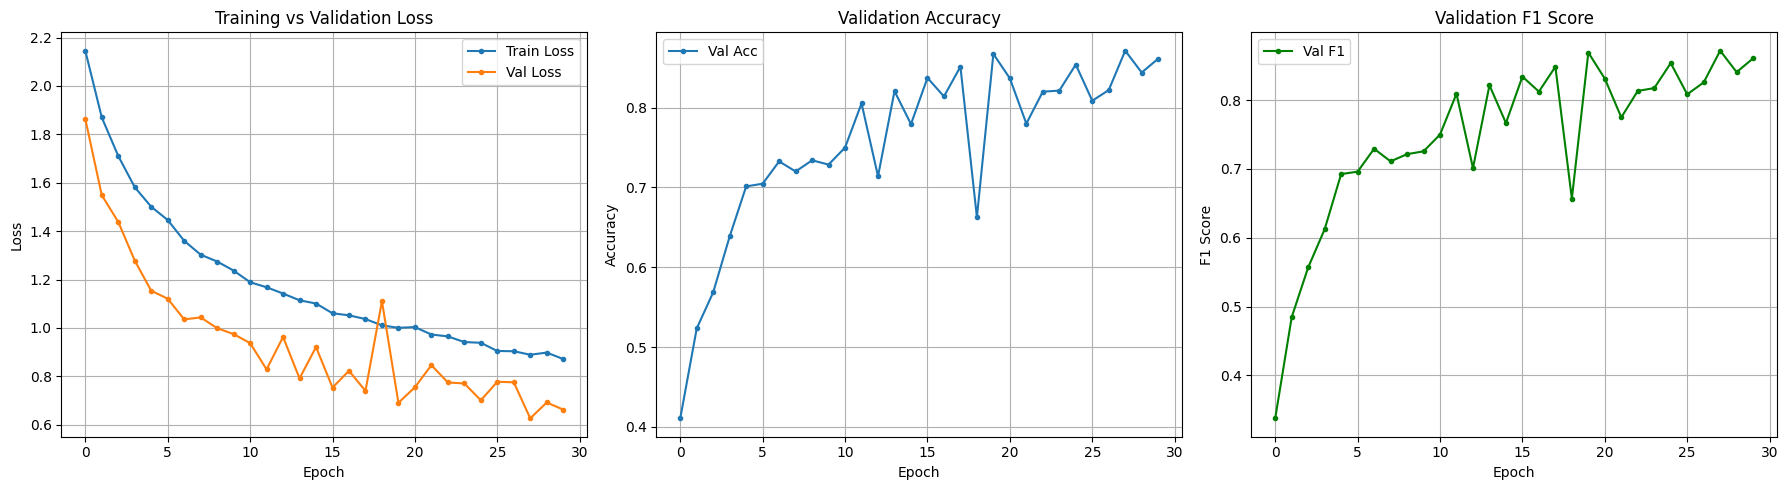

In [9]:
# Visualization and Analysis

ckpt = torch.load('/kaggle/working/best_cnn.pth', map_location=config.DEVICE, weights_only=False)
if hasattr(model, 'module'):
    model.module.load_state_dict(ckpt['state'])
else:
    model.load_state_dict(ckpt['state'])

model.eval()
all_preds = []
all_labels_list = []

with torch.no_grad():
    for spectrograms_batch, labels_batch in val_loader:
        spectrograms_batch = spectrograms_batch.to(config.DEVICE)
        with autocast():
            outputs = model(spectrograms_batch)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_list.extend(labels_batch.argmax(1).numpy())

print("\n ----- CLASSIFICATION REPORT -----")
cr = classification_report(
    all_labels_list,
    all_preds,
    target_names=config.GENRES,
    digits=4
)
print(cr)
print()

cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=config.GENRES,
    yticklabels=config.GENRES
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(metrics['train_loss'], label='Train Loss', marker='o', markersize=3)
axes[0].plot(metrics['val_loss'], label='Val Loss', marker='o', markersize=3)
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(metrics['val_acc'], label='Val Acc', marker='o', markersize=3)
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(metrics['val_f1'], label='Val F1', marker='o', markersize=3, color='green')
axes[2].set_title('Validation F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Inference on Test Data 

test_df = pd.read_csv(config.TEST_CSV)
print(f"Test samples: {len(test_df)}")

test_dataset = TestDataset(config.MASHUPS_PATH, test_df, n_crops=config.TTA_CROPS)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print("Running inference with TTA...")
predictions, all_probs = predict_tta(model, test_loader, config.DEVICE)

submission = pd.DataFrame([{'id': k, 'genre': v} for k, v in predictions.items()])
submission['id'] = submission['id'].astype(int)
submission = submission.sort_values('id')
submission['id'] = submission['id'].astype(str).str.zfill(4)
submission.to_csv('submission.csv', index=False)

total_time = time.time() - total_start

print(f"\nTotal time: {total_time/3600:.1f} hrs")
print(f"Best Validation F1: {best_f1:.4f}")
print(f"\nPrediction distribution:")
print(submission['genre'].value_counts().sort_index())

confs = np.array([p.max() for p in all_probs.values()])
print(f"\nConfidence: mean={confs.mean():.4f}, min={confs.min():.4f}")
print(f"  >0.90: {(confs > 0.90).sum()}")
print(f"  <0.50: {(confs < 0.50).sum()}")

Test samples: 3020
Running inference with TTA...


Inference: 100%|██████████| 378/378 [09:13<00:00,  1.47s/it]


Total time: 4.2 hrs
Best Validation F1: 0.8719

Prediction distribution:
genre
blues        185
classical    402
country      270
disco        281
hiphop       309
jazz         378
metal        316
pop          317
reggae       261
rock         301
Name: count, dtype: int64

Confidence: mean=0.6201, min=0.1595
  >0.90: 314
  <0.50: 964
